# Install dependencies

In [1]:
!uv add pandas scikit-learn matplotlib numpy

Resolved 19 packages in 0.66ms
Audited 17 packages in 1ms


# Read dataset

In [2]:
import pandas as pd

df = pd.read_csv("../dataset/creditcard.csv")

In [3]:
print(f"Number of rows {df.shape[0]}")
print(f"Number of columns {df.shape[1]}")

Number of rows 284807
Number of columns 31


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

# Checking for missing data

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Check Features/ Class imbalance

In [7]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

# Visualization

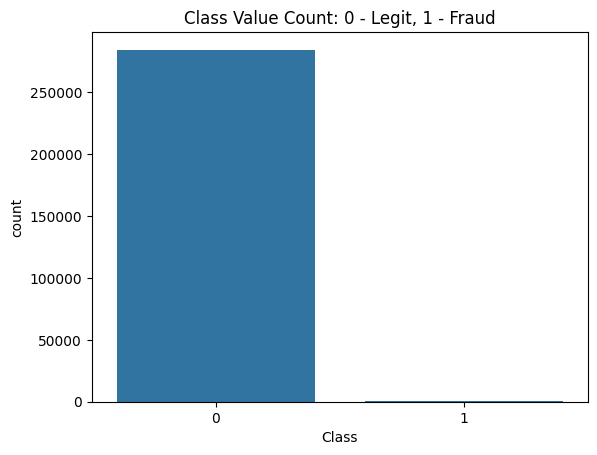

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)
plt.title("Class Value Count: 0 - Legit, 1 - Fraud")
plt.show()

# Analysis of Transaction Amount

In [13]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Text(0.5, 1.0, 'Transaction amount count vs amount')

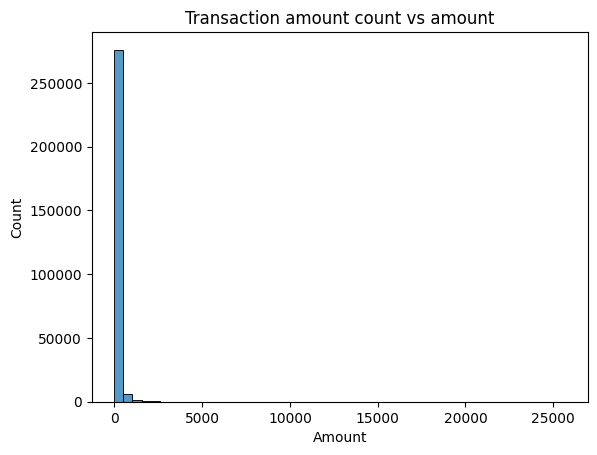

In [17]:
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction amount count vs amount")

/home/abrar/Projects/credit_card_fraud_detection/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


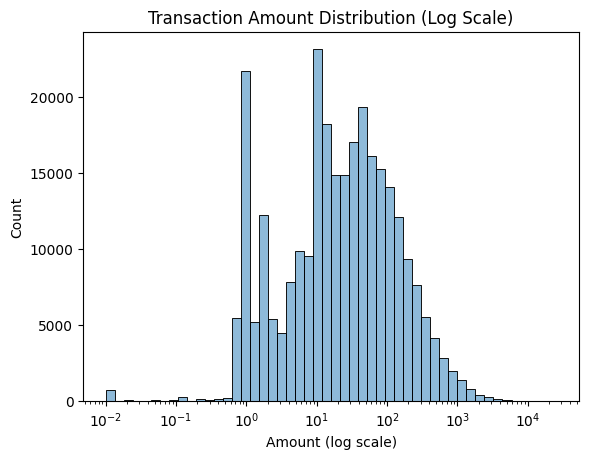

In [18]:
sns.histplot(df['Amount'], bins=50, log_scale=(True, False), kde=True)   # log x-axis only
plt.xlabel('Amount (log scale)')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.show()

This log figure shows that maximum of data lies between 100-1000

Text(0.5, 1.0, 'Box plot for comparing amount for legit and fraud transaction')

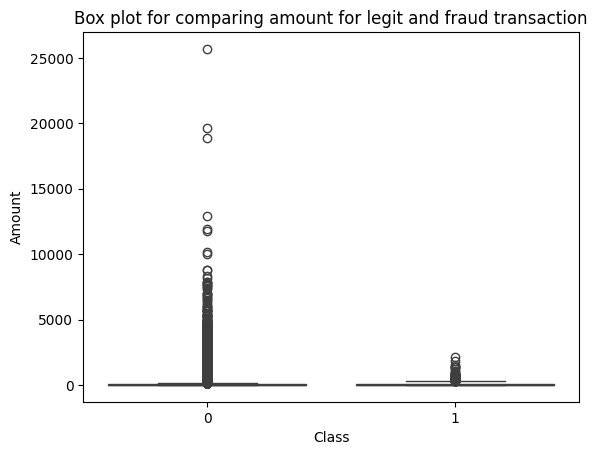

In [20]:
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Box plot for comparing amount for legit and fraud transaction")

# Analysis of Time Feature

In [21]:
df['Hour'] = df['Time'] // 3600

<Axes: xlabel='Hour', ylabel='Count'>

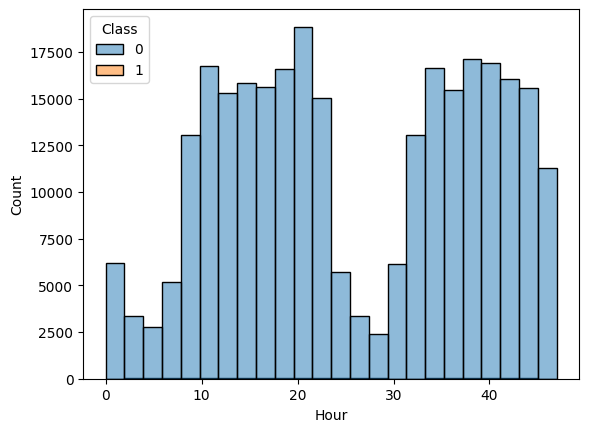

In [22]:
sns.histplot(data=df, x="Hour", hue="Class", bins=24)

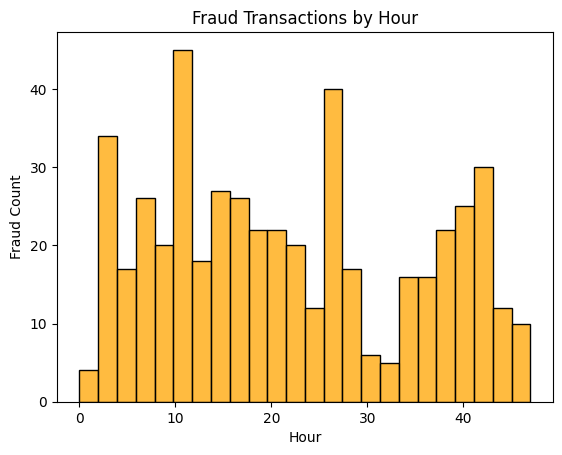

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, color='orange')
plt.xlabel('Hour')
plt.ylabel('Fraud Count')
plt.title('Fraud Transactions by Hour')
plt.show()

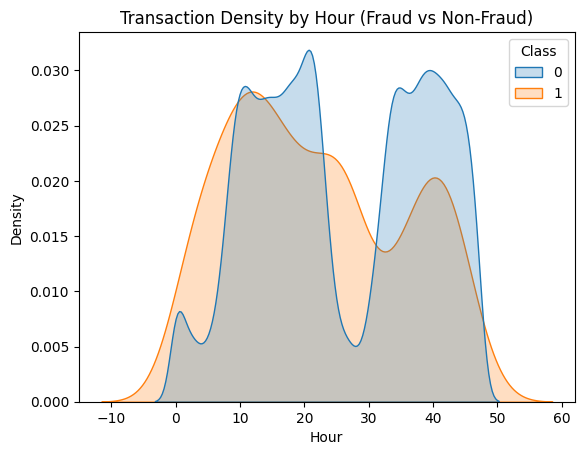

In [24]:
sns.kdeplot(data=df, x='Hour', hue='Class', common_norm=False, fill=True)
plt.xlabel('Hour')
plt.title('Transaction Density by Hour (Fraud vs Non-Fraud)')
plt.show()

# Feature Distribution

<Axes: xlabel='V1', ylabel='Count'>

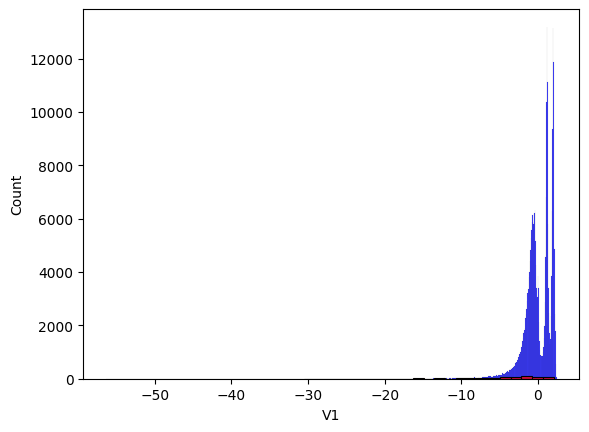

In [30]:
sns.histplot(df[df['Class']==0]['V1'], color="blue")
sns.histplot(df[df['Class']==1]['V1'], color="red")


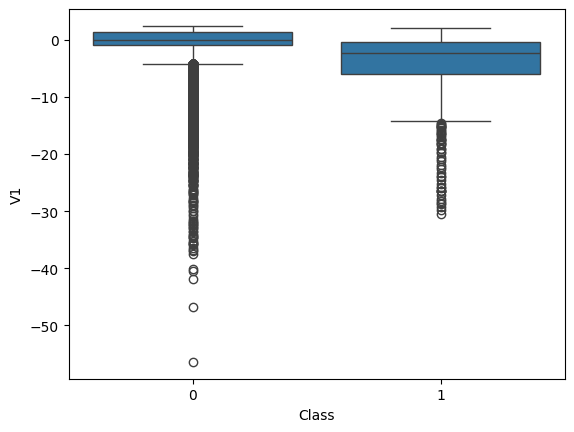

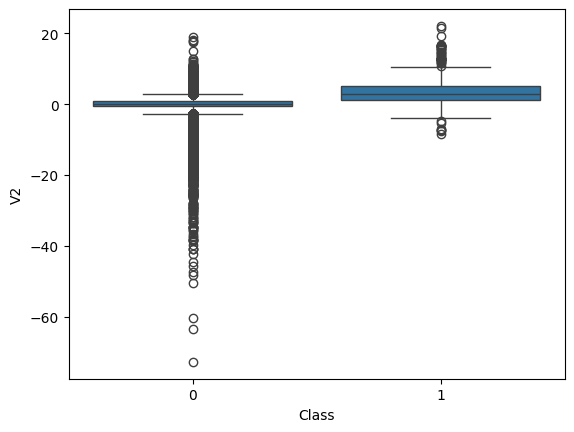

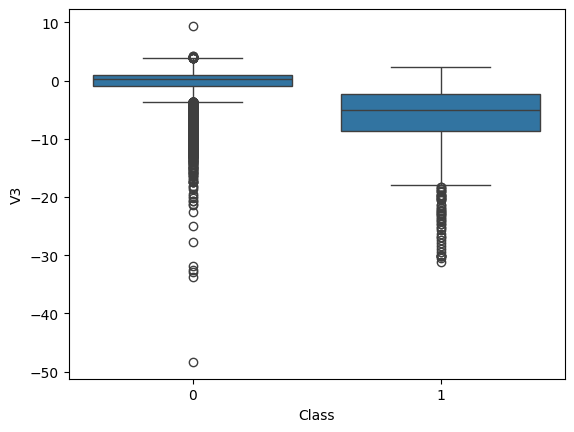

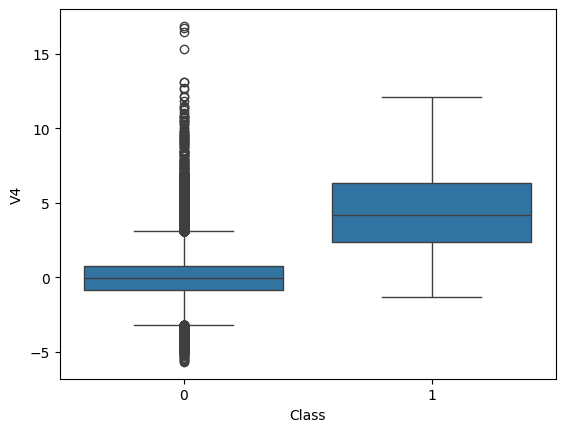

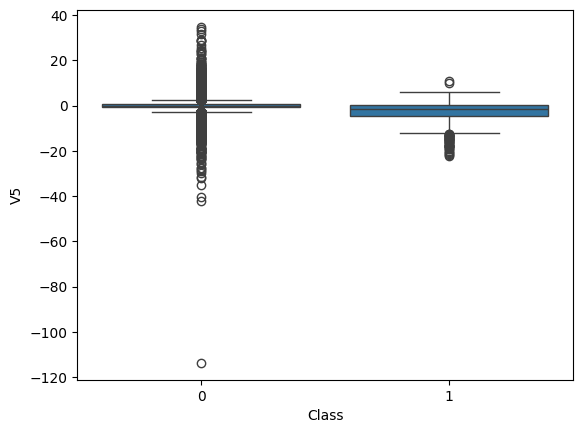

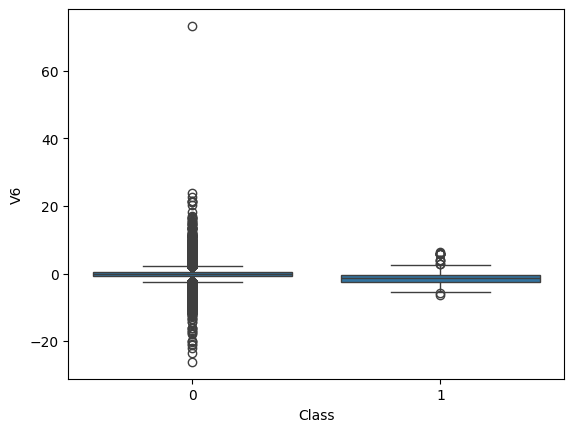

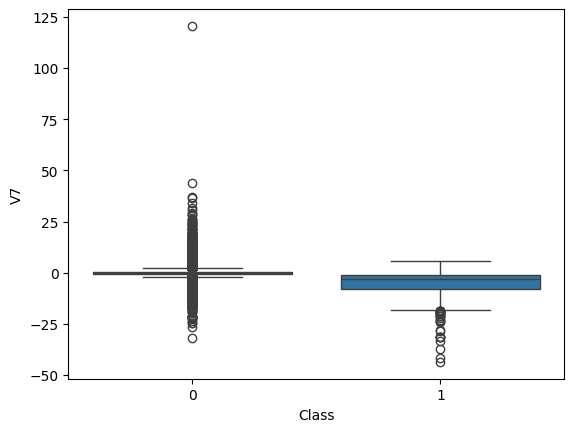

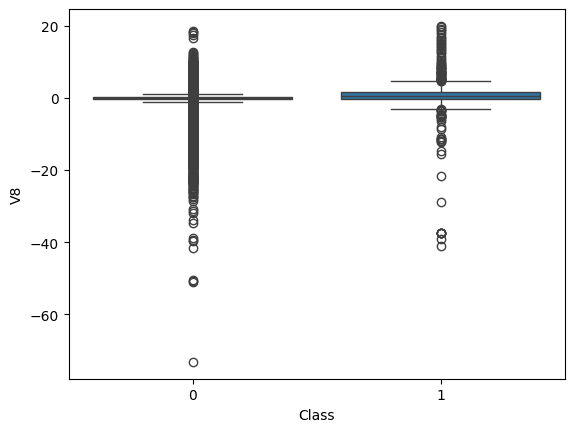

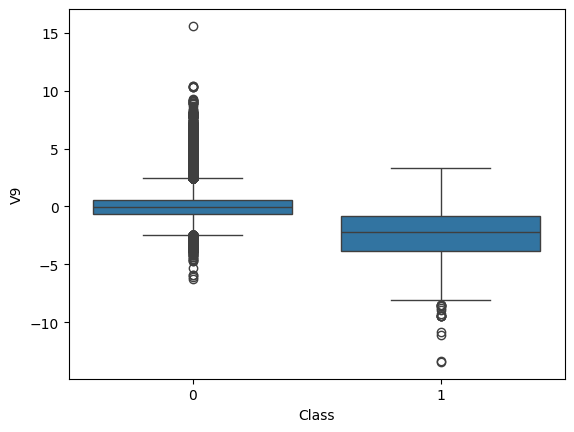

In [28]:
for col in df.columns[1:10]:
    sns.boxplot(x='Class', y=col, data=df)
    plt.show()

<Axes: >

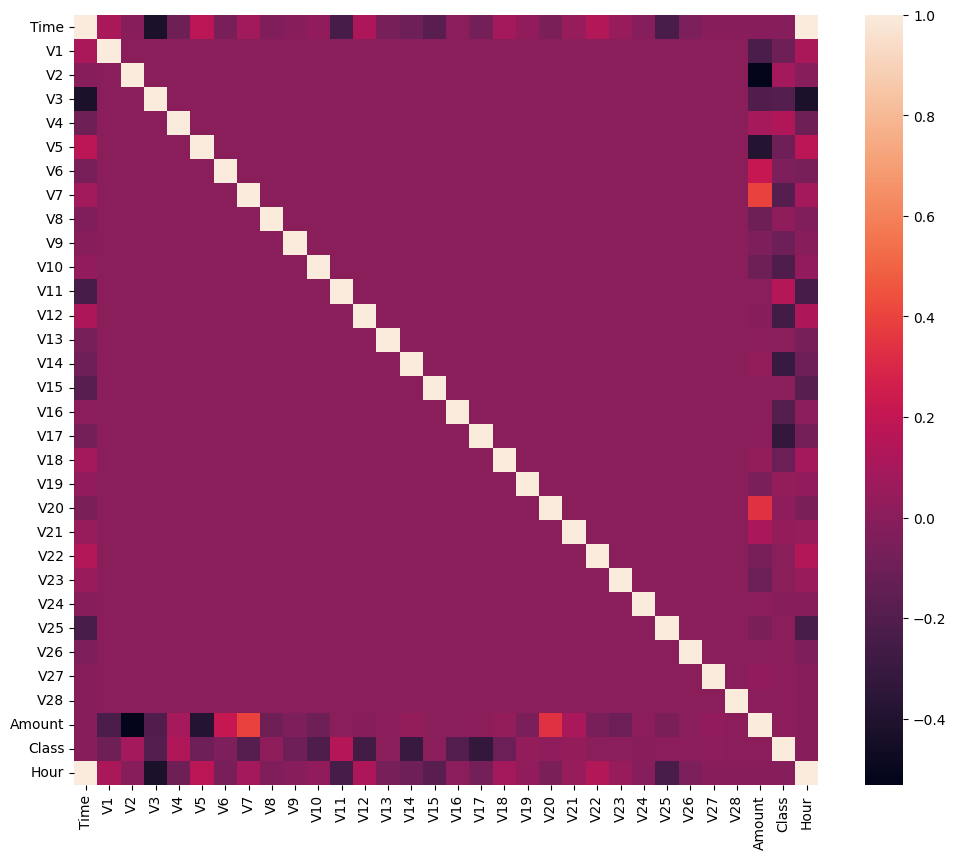

In [31]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr)